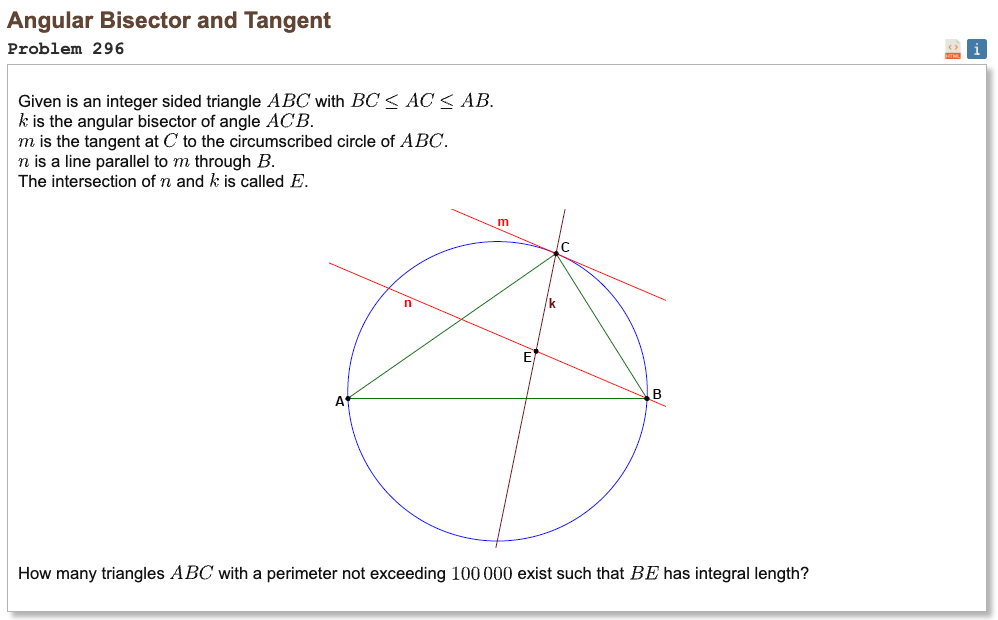

## Initial approach

* first turn the geometry into a divisibility condition for the third side
* after reducing the two smaller sides by their gcd, the sum of the reduced pair must divide the largest side
* this lets each triangle be described by a coprime reduced pair and one scale value, instead of scanning all side triples
* for a fixed reduced pair, the valid largest sides form a regular pattern, so the count becomes a floor sum problem
* then use mobius inversion to count only coprime reduced pairs without looping through them one by one
* that changes the whole problem from a huge brute force search into a manageable arithmetic summation
* the main helper is a fast floor sum routine, plus divisor lists weighted by mobius values

In [1]:
from functools import lru_cache

def floor_sum(n, m, a, b):
    total = 0
    while True:
        if a >= m:
            total += (n - 1) * n * (a // m) // 2
            a %= m
        if b >= m:
            total += n * (b // m)
            b %= m
        y = a * n + b
        if y < m:
            return total
        n, b = divmod(y, m)
        a, m = m, a

def mobius_sieve(limit):
    mu = [1] * (limit + 1)
    is_composite = [False] * (limit + 1)
    primes = []
    mu[0] = 0

    for i in range(2, limit + 1):
        if not is_composite[i]:
            primes.append(i)
            mu[i] = -1
        for p in primes:
            if i * p > limit:
                break
            is_composite[i * p] = True
            if i % p == 0:
                mu[i * p] = 0
                break
            mu[i * p] = -mu[i]

    return mu

def build_divisors_with_mu(limit, mu):
    divisors = [[] for _ in range(limit + 1)]
    for d in range(1, limit + 1):
        if mu[d] == 0:
            continue
        for m in range(d, limit + 1, d):
            divisors[m].append((d, mu[d]))
    return divisors

def sum_floor(q, n, r):
    if r <= 0:
        return 0
    return floor_sum(r + 1, n, q, 0)

def solve(limit):
    mu = mobius_sieve(limit)
    divisors = build_divisors_with_mu(limit, mu)

    @lru_cache(None)
    def coprime_count(m, x):
        if x <= 0:
            return 0
        total = 0
        for d, md in divisors[m]:
            total += md * (x // d)
        return total

    @lru_cache(None)
    def coprime_floor_sum(m, q, x):
        if x <= 0:
            return 0
        total = 0
        for d, md in divisors[m]:
            total += md * sum_floor(q, m // d, x // d)
        return total

    total = 0

    for m in range(2, limit + 1):
        M = limit // m
        if M < 2:
            break

        half = m // 2
        split = M // 2

        for q in range(1, split + 1):
            total += coprime_floor_sum(m, q, half)

        for q in range(split + 1, M):
            t = 2 * q - M - 1
            left = ((t + 1) * m + q - 1) // q
            if left <= half:
                total += (
                    coprime_floor_sum(m, q, half)
                    - coprime_floor_sum(m, q, left - 1)
                    - t * (coprime_count(m, half) - coprime_count(m, left - 1))
                )

    return total

In [2]:
%%time
result = solve(100000)
print("Result:", result)

Result: 1137208419
CPU times: user 1.72 s, sys: 44.9 ms, total: 1.77 s
Wall time: 1.77 s
